In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

Matplotlib is building the font cache; this may take a moment.


In [4]:
import pandas as pd

df = pd.read_csv("../data/processed/hdfc_top100_nav_clean.csv")

df.head()

,date,nav
0,2026-06-19,202.0761
1,2026-06-18,200.9565
2,2026-06-17,199.8302
3,2026-06-16,198.6152
4,2026-06-15,198.0320


In [5]:
print(df.columns.tolist())

['date', 'nav']


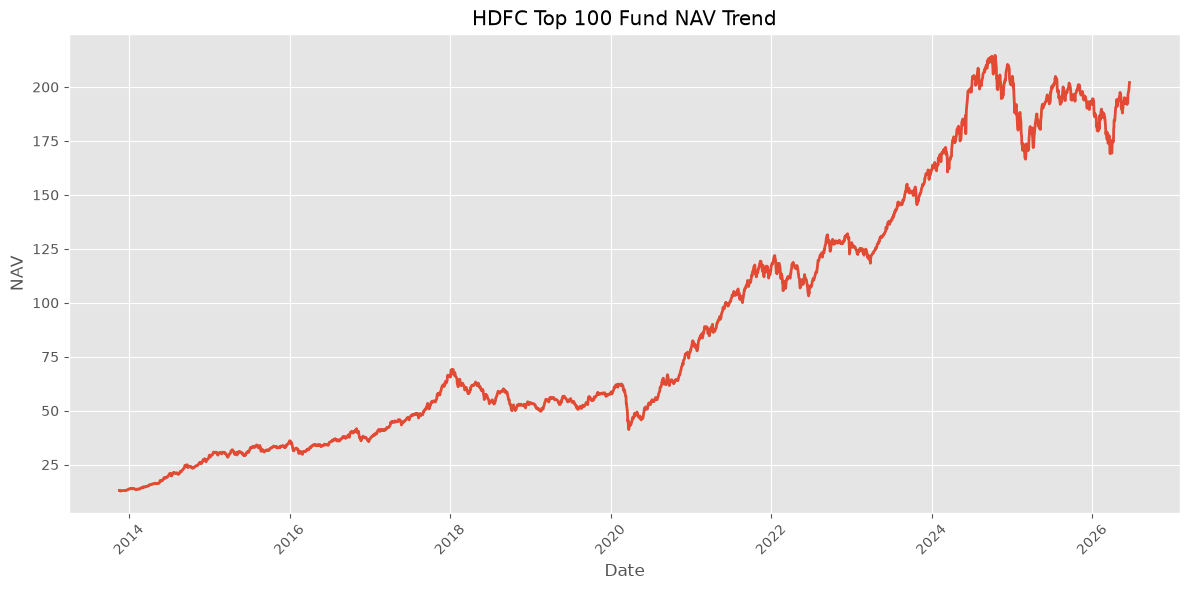

In [6]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Sort by date
df = df.sort_values('date')

plt.figure(figsize=(12,6))
plt.plot(df['date'], df['nav'], linewidth=2)

plt.title("HDFC Top 100 Fund NAV Trend")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../charts/nav_trend.png")

plt.show()

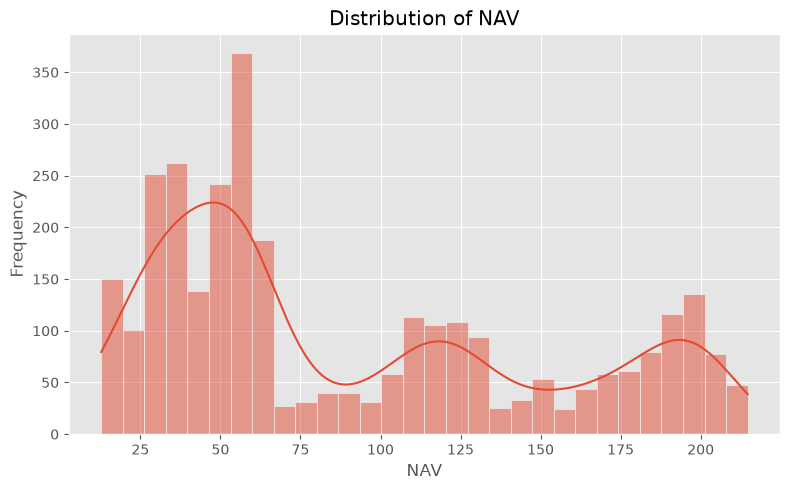

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df['nav'], bins=30, kde=True)

plt.title("Distribution of NAV")
plt.xlabel("NAV")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../charts/nav_distribution.png")

plt.show()

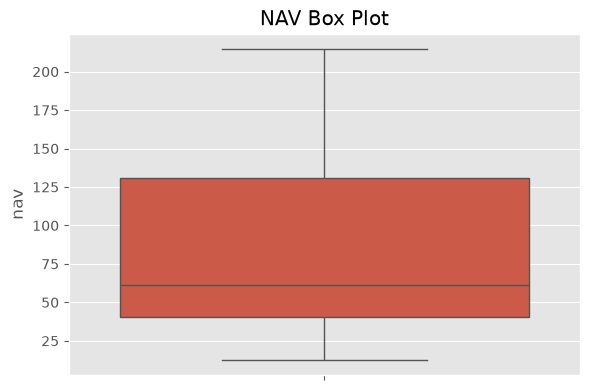

In [8]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df['nav'])

plt.title("NAV Box Plot")

plt.tight_layout()

plt.savefig("../charts/nav_boxplot.png")

plt.show()

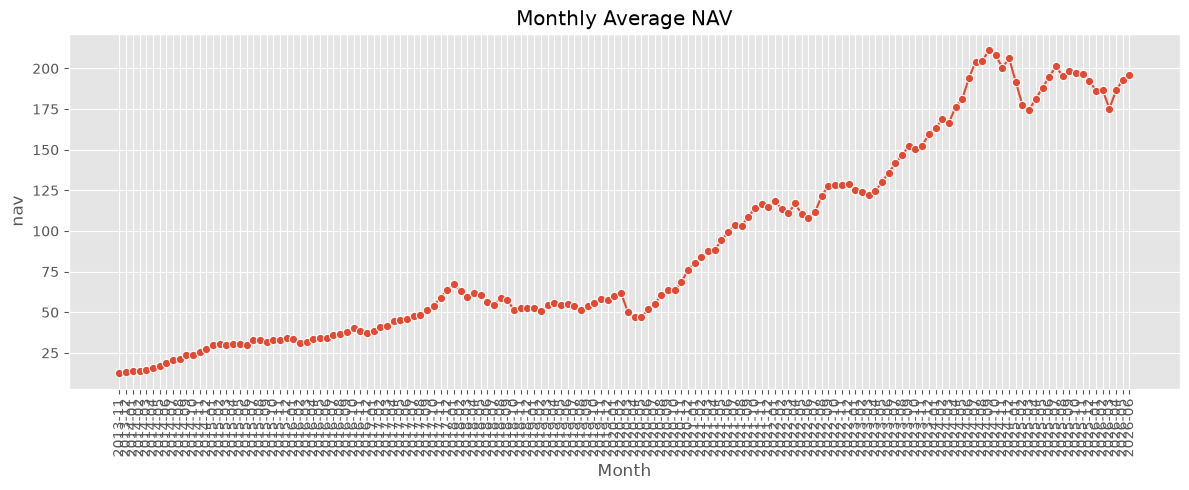

In [9]:
df['Month'] = df['date'].dt.to_period('M')

monthly = df.groupby('Month')['nav'].mean().reset_index()

monthly['Month'] = monthly['Month'].astype(str)

plt.figure(figsize=(12,5))

sns.lineplot(data=monthly, x='Month', y='nav', marker='o')

plt.xticks(rotation=90)

plt.title("Monthly Average NAV")

plt.tight_layout()

plt.savefig("../charts/monthly_nav.png")

plt.show()

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def generate_charts(file_path, name):

    df = pd.read_csv(file_path)

    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')

    # Trend
    plt.figure(figsize=(12,5))
    plt.plot(df['date'], df['nav'])
    plt.title(f"{name} Trend")
    plt.tight_layout()
    plt.savefig(f"../charts/{name}_trend.png")
    plt.close()

    # Distribution
    plt.figure(figsize=(7,4))
    sns.histplot(df['nav'], kde=True)
    plt.title(f"{name} Distribution")
    plt.tight_layout()
    plt.savefig(f"../charts/{name}_distribution.png")
    plt.close()

    # Boxplot
    plt.figure(figsize=(5,4))
    sns.boxplot(y=df['nav'])
    plt.title(f"{name} Boxplot")
    plt.tight_layout()
    plt.savefig(f"../charts/{name}_boxplot.png")
    plt.close()

    print(name, "Completed")

In [12]:
df = pd.read_csv("../data/processed/hdfcbank_clean.csv")
print(df.columns.tolist())
df.head()

['Price', 'Close', 'High', 'Low', 'Open', 'Volume']


,Price,Close,High,Low,Open,Volume
0,Ticker,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS
1,2022-01-03,711.0422973632812,712.6097466433577,692.7240511526534,694.8295953810808,9069184
2,2022-01-04,715.2066650390625,717.242013200678,705.4977658695926,711.2061078358669,8857352
3,2022-01-05,732.1913452148438,735.5368326901471,714.9960662063432,719.0668195884875,14332638
4,2022-01-06,720.4470825195312,727.4655635961949,715.9084876032401,721.967753419475,9628930


In [13]:
import pandas as pd

files = [
    "hdfcbank_clean.csv",
    "icicibank_clean.csv",
    "sbi_clean.csv",
    "nifty50_clean.csv",
    "sensex_clean.csv"
]

for file in files:
    df = pd.read_csv("../data/processed/" + file)
    print(file)
    print(df.columns.tolist())
    print()

hdfcbank_clean.csv
['Price', 'Close', 'High', 'Low', 'Open', 'Volume']

icicibank_clean.csv
['Price', 'Close', 'High', 'Low', 'Open', 'Volume']

sbi_clean.csv
['Price', 'Close', 'High', 'Low', 'Open', 'Volume']

nifty50_clean.csv
['Price', 'Close', 'High', 'Low', 'Open', 'Volume']

sensex_clean.csv
['Price', 'Close', 'High', 'Low', 'Open', 'Volume']



In [14]:
df = pd.read_csv("../data/processed/hdfcbank_clean.csv")
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS
1,2022-01-03,711.0422973632812,712.6097466433577,692.7240511526534,694.8295953810808,9069184
2,2022-01-04,715.2066650390625,717.242013200678,705.4977658695926,711.2061078358669,8857352
3,2022-01-05,732.1913452148438,735.5368326901471,714.9960662063432,719.0668195884875,14332638
4,2022-01-06,720.4470825195312,727.4655635961949,715.9084876032401,721.967753419475,9628930


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def generate_charts(file_path, name):

    df = pd.read_csv(file_path)

    # Remove first row (Ticker row)
    df = df.iloc[1:].copy()

    # Rename columns
    df.rename(columns={
        "Price": "date",
        "Close": "price"
    }, inplace=True)

    # Convert datatypes
    df["date"] = pd.to_datetime(df["date"])
    df["price"] = pd.to_numeric(df["price"])

    df = df.sort_values("date")

    # Trend
    plt.figure(figsize=(12,5))
    plt.plot(df["date"], df["price"])
    plt.title(f"{name} Price Trend")
    plt.tight_layout()
    plt.savefig(f"../charts/{name}_trend.png")
    plt.close()

    # Distribution
    plt.figure(figsize=(6,4))
    sns.histplot(df["price"], kde=True)
    plt.title(f"{name} Price Distribution")
    plt.tight_layout()
    plt.savefig(f"../charts/{name}_distribution.png")
    plt.close()

    # Boxplot
    plt.figure(figsize=(5,4))
    sns.boxplot(y=df["price"])
    plt.title(f"{name} Boxplot")
    plt.tight_layout()
    plt.savefig(f"../charts/{name}_boxplot.png")
    plt.close()

    print(name, "Done")

In [16]:
generate_charts("../data/processed/hdfcbank_clean.csv", "hdfcbank")
generate_charts("../data/processed/icicibank_clean.csv", "icicibank")
generate_charts("../data/processed/sbi_clean.csv", "sbi")
generate_charts("../data/processed/nifty50_clean.csv", "nifty50")
generate_charts("../data/processed/sensex_clean.csv", "sensex")

hdfcbank Done
icicibank Done
sbi Done
nifty50 Done
sensex Done
